## Import libraries & set random seed

In [ ]:
import numpy as np
import pandas as pd
import os
import random
import warnings
import cv2
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.backends.cudnn as cudnn
import torch.optim as optim
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from tqdm import tqdm

warnings.filterwarnings('ignore')

manualSeed = 999
random.seed(manualSeed)
torch.manual_seed(manualSeed)

image_dir = '/kaggle/input/isic-2024-challenge/train-image/image'
image_files = os.listdir(image_dir)[:10]

for i, file_name in enumerate(image_files, 1):
    image_path = os.path.join(image_dir, file_name)
    with Image.open(image_path) as img:
        print(f"Image {i}: {file_name} - Size: {img.size}")

Random Seed:  999
Image 1: ISIC_9730802.jpg - Size: (139, 139)
Image 2: ISIC_2834883.jpg - Size: (125, 125)
Image 3: ISIC_5115027.jpg - Size: (123, 123)
Image 4: ISIC_3264822.jpg - Size: (115, 115)
Image 5: ISIC_1950204.jpg - Size: (147, 147)
Image 6: ISIC_8411738.jpg - Size: (145, 145)
Image 7: ISIC_3744117.jpg - Size: (133, 133)
Image 8: ISIC_0989720.jpg - Size: (131, 131)
Image 9: ISIC_3926794.jpg - Size: (139, 139)
Image 10: ISIC_2892810.jpg - Size: (107, 107)


## Load & Filter Data

In [ ]:
meta_dir = "/kaggle/input/competitions/isic-2024-challenge/"
df = pd.read_csv(meta_dir + "train-metadata.csv")
df.head()

,isic_id,target,patient_id,age_approx,sex,anatom_site_general,clin_size_long_diam_mm,image_type,tbp_tile_type,tbp_lv_A,...,lesion_id,iddx_full,iddx_1,iddx_2,iddx_3,iddx_4,iddx_5,mel_mitotic_index,mel_thick_mm,tbp_lv_dnn_lesion_confidence
0,ISIC_0015670,0,IP_1235828,60.0,male,lower extremity,3.04,TBP tile: close-up,3D: white,20.244422,...,NaN,Benign,Benign,NaN,NaN,NaN,NaN,NaN,NaN,97.517282
1,ISIC_0015845,0,IP_8170065,60.0,male,head/neck,1.10,TBP tile: close-up,3D: white,31.712570,...,IL_6727506,Benign,Benign,NaN,NaN,NaN,NaN,NaN,NaN,3.141455
2,ISIC_0015864,0,IP_6724798,60.0,male,posterior torso,3.40,TBP tile: close-up,3D: XP,22.575830,...,NaN,Benign,Benign,NaN,NaN,NaN,NaN,NaN,NaN,99.804040
3,ISIC_0015902,0,IP_4111386,65.0,male,anterior torso,3.22,TBP tile: close-up,3D: XP,14.242329,...,NaN,Benign,Benign,NaN,NaN,NaN,NaN,NaN,NaN,99.989998
4,ISIC_0024200,0,IP_8313778,55.0,male,anterior torso,2.73,TBP tile: close-up,3D: white,24.725520,...,NaN,Benign,Benign,NaN,NaN,NaN,NaN,NaN,NaN,70.442510


## Visualize with the malignant skin cancer cells

In [ ]:
df_filtered = df[df["target"] == 1].reset_index(drop=True)
df_filtered.head()

,isic_id,target,patient_id,age_approx,sex,anatom_site_general,clin_size_long_diam_mm,image_type,tbp_tile_type,tbp_lv_A,...,lesion_id,iddx_full,iddx_1,iddx_2,iddx_3,iddx_4,iddx_5,mel_mitotic_index,mel_thick_mm,tbp_lv_dnn_lesion_confidence
0,ISIC_0082829,1,IP_3249371,80.0,female,anterior torso,9.27,TBP tile: close-up,3D: XP,18.093368,...,IL_7881385,Malignant::Malignant epidermal proliferations:...,Malignant,Malignant epidermal proliferations,Squamous cell carcinoma in situ,NaN,NaN,NaN,NaN,72.211683
1,ISIC_0096034,1,IP_6723298,75.0,male,head/neck,3.88,TBP tile: close-up,3D: white,26.187010,...,IL_5240575,Malignant::Malignant adnexal epithelial prolif...,Malignant,Malignant adnexal epithelial proliferations - ...,Basal cell carcinoma,"Basal cell carcinoma, Nodular",NaN,NaN,NaN,94.559590
2,ISIC_0104229,1,IP_9057861,80.0,male,anterior torso,6.55,TBP tile: close-up,3D: white,33.480140,...,IL_1702337,Malignant::Malignant adnexal epithelial prolif...,Malignant,Malignant adnexal epithelial proliferations - ...,Basal cell carcinoma,"Basal cell carcinoma, Nodular",NaN,NaN,NaN,66.196170
3,ISIC_0119495,1,IP_6856511,60.0,male,upper extremity,5.27,TBP tile: close-up,3D: white,25.872050,...,IL_3266850,Malignant::Malignant epidermal proliferations:...,Malignant,Malignant epidermal proliferations,"Squamous cell carcinoma, Invasive",NaN,NaN,NaN,NaN,99.991270
4,ISIC_0157834,1,IP_3927284,55.0,male,posterior torso,5.29,TBP tile: close-up,3D: white,30.966662,...,IL_2429082,Malignant::Malignant adnexal epithelial prolif...,Malignant,Malignant adnexal epithelial proliferations - ...,Basal cell carcinoma,"Basal cell carcinoma, Superficial",NaN,NaN,NaN,99.960846


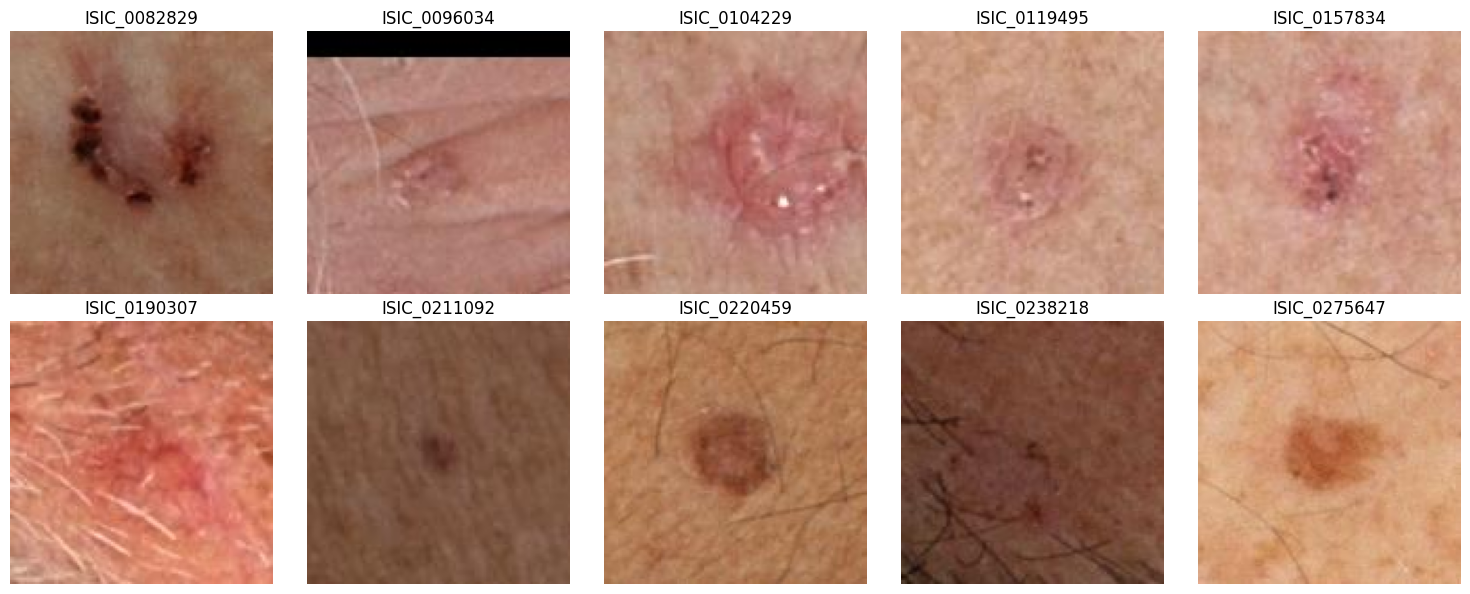

In [ ]:
isic_ids = df_filtered['isic_id'].head(10)

plt.figure(figsize=(15, 6))
for i, isic_id in enumerate(isic_ids):
    image_path = os.path.join(image_dir, f"{isic_id}.jpg")
    img = Image.open(image_path).convert("RGB")
    plt.subplot(2, 5, i + 1)
    plt.imshow(img)
    plt.title(isic_id)
    plt.axis('off')

plt.tight_layout()
plt.show()

## Apply yuv clahe preprocessing technique

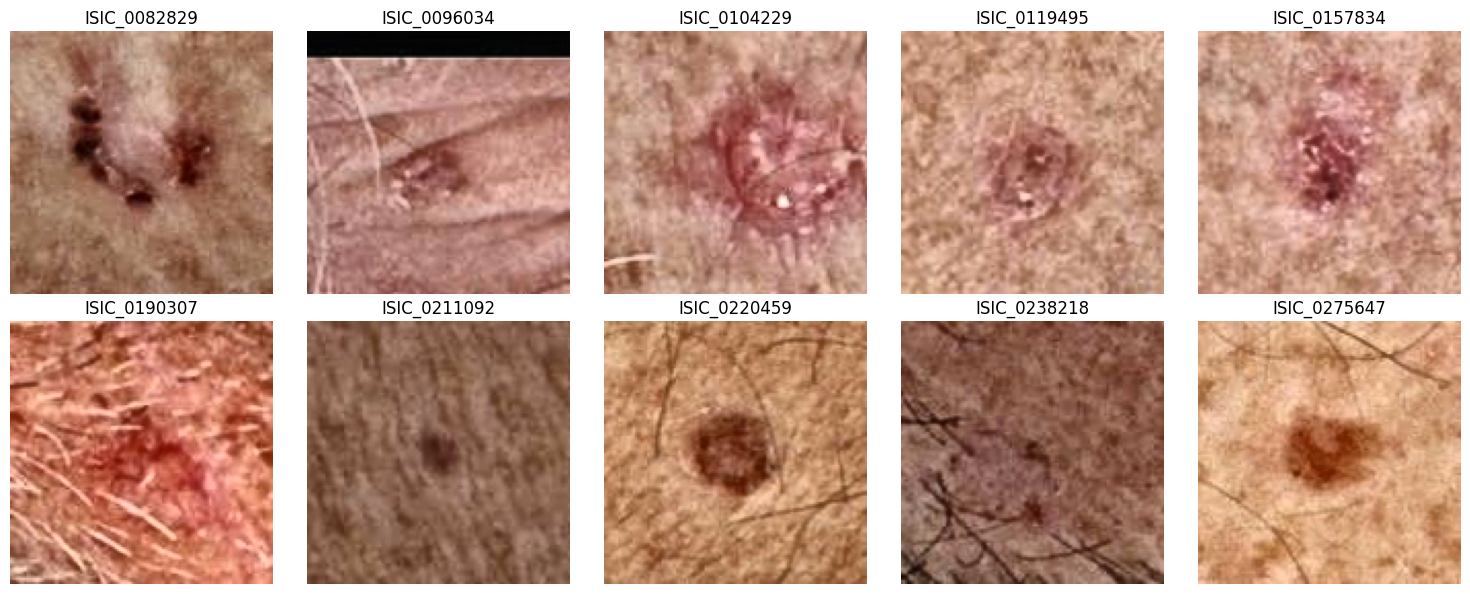

In [ ]:
save_dir = '/kaggle/working/clahe_images'
os.makedirs(save_dir, exist_ok=True)

isic_ids = df_filtered['isic_id'].head(10)
plt.figure(figsize=(15, 6))

for i, isic_id in enumerate(isic_ids):
    path = os.path.join(image_dir, f"{isic_id}.jpg")
    img = cv2.imread(path)
    if img is None:
        continue

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (128, 128), interpolation=cv2.INTER_CUBIC)

    yuv = cv2.cvtColor(img, cv2.COLOR_RGB2YUV)
    y_channel = yuv[:, :, 0]
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(4, 4))
    yuv[:, :, 0] = clahe.apply(y_channel)
    clahe_img = cv2.cvtColor(yuv, cv2.COLOR_YUV2RGB)

    save_path = os.path.join(save_dir, f"{isic_id}_clahe.jpg")
    cv2.imwrite(save_path, cv2.cvtColor(clahe_img, cv2.COLOR_RGB2BGR))

    plt.subplot(2, 5, i + 1)
    plt.imshow(clahe_img)
    plt.title(isic_id)
    plt.axis('off')

plt.tight_layout()
plt.show()

## Apply LAB clahe preprocessing technique

In [ ]:
save_dir_lab = '/kaggle/working/clahe_images_lab_preview'
os.makedirs(save_dir_lab, exist_ok=True)

isic_ids = df_filtered['isic_id'].head(10)
plt.figure(figsize=(15, 6))

for i, isic_id in enumerate(isic_ids):
    path = os.path.join(image_dir, f"{isic_id}.jpg")
    img = cv2.imread(path)
    if img is None:
        continue

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (128, 128), interpolation=cv2.INTER_CUBIC)

    lab = cv2.cvtColor(img, cv2.COLOR_RGB2Lab)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    l_clahe = clahe.apply(l)
    lab_clahe = cv2.merge((l_clahe, a, b))
    img_clahe = cv2.cvtColor(lab_clahe, cv2.COLOR_Lab2RGB)

    save_path = os.path.join(save_dir_lab, f"{isic_id}_clahe.jpg")
    cv2.imwrite(save_path, cv2.cvtColor(img_clahe, cv2.COLOR_RGB2BGR))

    plt.subplot(2, 5, i + 1)
    plt.imshow(img_clahe)
    plt.title(isic_id)
    plt.axis('off')

plt.tight_layout()
plt.show()

## Define Dataset Class

In [ ]:
class SkinLesionDataset(Dataset):
    def __init__(self, df, img_dir, transform=None):
        self.df = df
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        isic_id = self.df.iloc[idx]["isic_id"]
        label = self.df.iloc[idx]["target"]
        img_path = os.path.join(self.img_dir, f"{isic_id}.jpg")
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, label

## EfficientNet Binary Classifier model

In [ ]:
class EfficientNetBinaryClassifier(nn.Module):
    def __init__(self, pretrained=True):
        super().__init__()
        weights = EfficientNet_B0_Weights.IMAGENET1K_V1 if pretrained else None
        self.backbone = efficientnet_b0(weights=weights)

        in_feats = self.backbone.classifier[1].in_features
        self.backbone.classifier = nn.Sequential(
            nn.Dropout(p=0.4, inplace=True),
            nn.Linear(in_feats, 1)
        )

    def forward(self, x):
        return self.backbone(x)

## Model, Optimizer & Scheduler Setup

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = EfficientNetBinaryClassifier(pretrained=True).to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=2, gamma=0.8)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth
100%|██████████| 20.5M/20.5M [00:00<00:00, 152MB/s]


## Hair remove function dullrazor 

In [ ]:
def remove_hairs_dullrazor(img):
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (17, 17))
    blackhat = cv2.morphologyEx(gray, cv2.MORPH_BLACKHAT, kernel)
    _, hair_mask = cv2.threshold(blackhat, 10, 255, cv2.THRESH_BINARY)
    hair_mask = cv2.dilate(hair_mask, np.ones((3, 3), np.uint8), iterations=1)
    inpainted = cv2.inpaint(img, hair_mask, inpaintRadius=1, flags=cv2.INPAINT_TELEA)
    return inpainted

## Experiment with different Preprocessing techniques | YUV CLAHE + Hair removal Functions

In [ ]:
def apply_clahe_yuv(img):
    yuv = cv2.cvtColor(img, cv2.COLOR_RGB2YUV)
    y_channel = yuv[:, :, 0]
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(4, 4))
    yuv[:, :, 0] = clahe.apply(y_channel)
    return cv2.cvtColor(yuv, cv2.COLOR_YUV2RGB)

def augment_image(img):
    aug_imgs = []
    for angle in [90, 180, 270]:
        rotated = cv2.rotate(img, {
            90: cv2.ROTATE_90_CLOCKWISE,
            180: cv2.ROTATE_180,
            270: cv2.ROTATE_90_COUNTERCLOCKWISE
        }[angle])
        aug_imgs.append(rotated)
        aug_imgs.append(cv2.flip(rotated, 1))
    return aug_imgs

image_dir = '/kaggle/input/isic-2024-challenge/train-image/image'
save_dir = '/kaggle/working/clahe_images_lab'
os.makedirs(save_dir, exist_ok=True)

malignant_df = df[df["target"] == 1]
benign_df = df[df["target"] == 0].sample(n=10000, random_state=42)
df_filtered = pd.concat([malignant_df, benign_df]).reset_index(drop=True)

new_records = []

for _, row in tqdm(df_filtered.iterrows(), total=len(df_filtered)):
    isic_id = row["isic_id"]
    label = row["target"]
    img_path = os.path.join(image_dir, f"{isic_id}.jpg")
    save_path = os.path.join(save_dir, f"{isic_id}.jpg")

    img = cv2.imread(img_path)
    if img is None:
        print(f"Failed to read: {img_path}")
        continue

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (224, 224))
    img = remove_hairs_dullrazor(img)
    img = apply_clahe_yuv(img)

    cv2.imwrite(save_path, cv2.cvtColor(img, cv2.COLOR_RGB2BGR))
    new_records.append({'isic_id': isic_id, 'target': label})


df_filtered = pd.DataFrame(new_records).reset_index(drop=True)
print(f"Final dataset size: {len(df_filtered)}")
df_filtered.head()

100%|██████████| 10393/10393 [19:12<00:00,  9.02it/s]

✅ Final dataset size: 12751


,isic_id,target
0,ISIC_0082829,1
1,ISIC_0082829_aug0,1
2,ISIC_0082829_aug1,1
3,ISIC_0082829_aug2,1
4,ISIC_0082829_aug3,1


## DataLoader Setup

In [ ]:
transform = transforms.Compose([
    transforms.RandomResizedCrop(128, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3)
])

train_df, val_df = train_test_split(df_filtered, test_size=0.2, stratify=df_filtered["target"], random_state=42)

train_dataset = SkinLesionDataset(train_df, save_dir, transform)
val_dataset = SkinLesionDataset(val_df, save_dir, transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)

## Before preprocessing and After preprocessing Skin cancer cells visualization

In [ ]:
def show_before_after(isic_ids, original_dir, processed_dir):
    plt.figure(figsize=(12, 10))
    for i, isic_id in enumerate(isic_ids):
        orig_path = os.path.join(original_dir, f"{isic_id}.jpg")
        orig_img = cv2.imread(orig_path)
        orig_img = cv2.cvtColor(orig_img, cv2.COLOR_BGR2RGB)

        proc_path = os.path.join(processed_dir, f"{isic_id}.jpg")
        proc_img = cv2.imread(proc_path)
        proc_img = cv2.cvtColor(proc_img, cv2.COLOR_BGR2RGB)

        plt.subplot(len(isic_ids), 2, 2 * i + 1)
        plt.imshow(orig_img)
        plt.title(f"Original - {isic_id}")
        plt.axis("off")

        plt.subplot(len(isic_ids), 2, 2 * i + 2)
        plt.imshow(proc_img)
        plt.title(f"Processed - {isic_id}")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

sample_ids = df_filtered[df_filtered["isic_id"].str.contains("aug") == False]["isic_id"].iloc[5:10].tolist()
original_dir = '/kaggle/input/competitions/isic-2024-challenge/train-image/image'
processed_dir = '/kaggle/working/without_any'

show_before_after(sample_ids, original_dir, processed_dir)

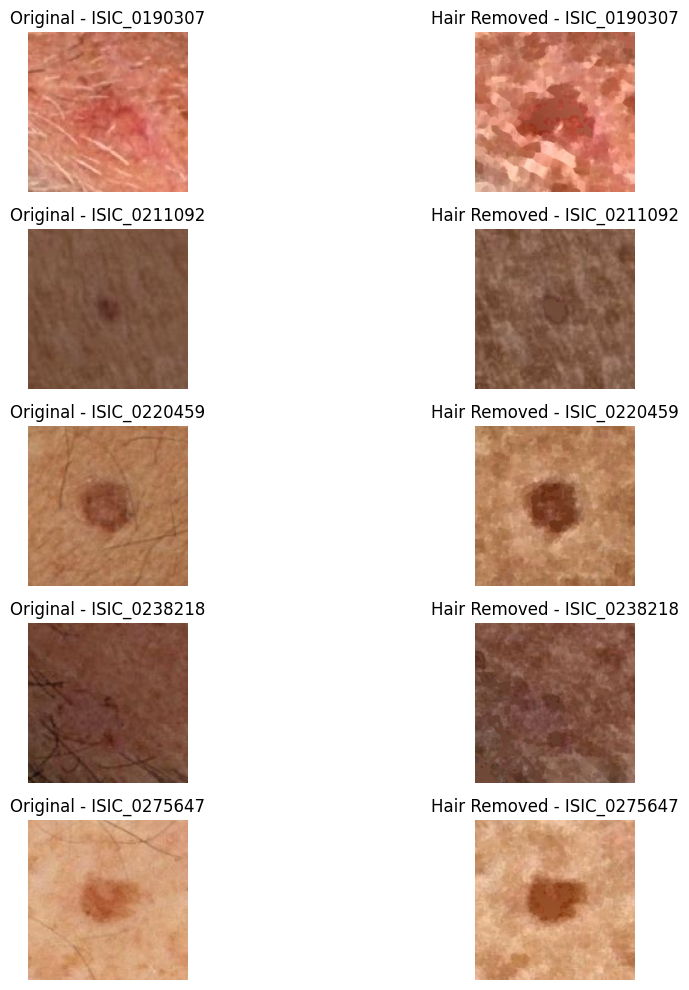

In [ ]:
sample_ids = df_filtered[df_filtered["isic_id"].str.contains("aug") == False]["isic_id"].iloc[5:10].tolist()
original_dir = '/kaggle/input/isic-2024-challenge/train-image/image'
processed_dir = '/kaggle/working/clahe_images_lab'

show_before_after(sample_ids, original_dir, processed_dir)

## Full training loop - run epochs | YUV-Clahe + Hair removal preprocessing Techniques

In [ ]:
scheduler.step()

for epoch in range(5):
    model.train()
    running_loss = 0.0
    train_preds, train_labels = [], []

    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device).float().unsqueeze(1)
        logits = model(imgs)
        loss = criterion(logits, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * imgs.size(0)
        preds = torch.sigmoid(logits).detach().cpu().numpy() > 0.5
        train_preds.extend(preds.flatten())
        train_labels.extend(labels.cpu().numpy())

    avg_train_loss = running_loss / len(train_loader.dataset)
    train_acc = accuracy_score(train_labels, train_preds)

    model.eval()
    val_loss = 0.0
    val_preds, val_labels = [], []

    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device).float().unsqueeze(1)
            logits = model(imgs)
            loss = criterion(logits, labels)
            val_loss += loss.item() * imgs.size(0)
            preds = torch.sigmoid(logits).cpu().numpy() > 0.5
            val_preds.extend(preds.flatten())
            val_labels.extend(labels.cpu().numpy())

    avg_val_loss = val_loss / len(val_loader.dataset)
    val_acc = accuracy_score(val_labels, val_preds)

    print(f"Epoch {epoch+1}: "
          f"Train Loss = {avg_train_loss:.4f}, Train Acc = {train_acc:.4f}, "
          f"Val Loss = {avg_val_loss:.4f}, Val Acc = {val_acc:.4f}")

Epoch 1: Train Loss = 0.3414, Train Acc = 0.8796, Val Loss = 0.2425, Val Acc = 0.9063
Epoch 2: Train Loss = 0.2271, Train Acc = 0.9070, Val Loss = 0.2061, Val Acc = 0.9177
Epoch 3: Train Loss = 0.1983, Train Acc = 0.9202, Val Loss = 0.1776, Val Acc = 0.9338
Epoch 4: Train Loss = 0.1729, Train Acc = 0.9323, Val Loss = 0.1605, Val Acc = 0.9349
Epoch 5: Train Loss = 0.1477, Train Acc = 0.9414, Val Loss = 0.1463, Val Acc = 0.9439


## Trained with Only clahe preprocessing 

Epoch 1: Train Loss = 0.0724, Train Acc = 0.9749, Val Loss = 0.0944, Val Acc = 0.9651

Epoch 2: Train Loss = 0.0611, Train Acc = 0.9791, Val Loss = 0.0722, Val Acc = 0.9726

Epoch 3: Train Loss = 0.0545, Train Acc = 0.9816, Val Loss = 0.0727, Val Acc = 0.9757

Epoch 4: Train Loss = 0.0461, Train Acc = 0.9840, Val Loss = 0.0875, Val Acc = 0.9726

Epoch 5: Train Loss = 0.0532, Train Acc = 0.9817, Val Loss = 0.0705, Val Acc = 0.9753

Epoch 6: Train Loss = 0.0448, Train Acc = 0.9855, Val Loss = 0.0754, Val Acc = 0.9741

Epoch 7: Train Loss = 0.0398, Train Acc = 0.9855, Val Loss = 0.0763, Val Acc = 0.9757

Epoch 8: Train Loss = 0.0340, Train Acc = 0.9881, Val Loss = 0.0717, Val Acc = 0.9757

Epoch 9: Train Loss = 0.0312, Train Acc = 0.9886, Val Loss = 0.0568, Val Acc = 0.9800

Epoch 10: Train Loss = 0.0342, Train Acc = 0.9880, Val Loss = 0.0731, Val Acc = 0.9765 


## Train using LAB-Clahe + Hair removal preprocessing Techniques

Epoch 1: Train Loss = 0.0158, Train Acc = 0.9938, Val Loss = 0.0559, Val Acc = 0.9839

Epoch 2: Train Loss = 0.0135, Train Acc = 0.9952, Val Loss = 0.0380, Val Acc = 0.9871

Epoch 3: Train Loss = 0.0124, Train Acc = 0.9959, Val Loss = 0.0450, Val Acc = 0.9843

Epoch 4: Train Loss = 0.0133, Train Acc = 0.9958, Val Loss = 0.0394, Val Acc = 0.9882

Epoch 5: Train Loss = 0.0113, Train Acc = 0.9959, Val Loss = 0.0331, Val Acc = 0.9898

Epoch 6: Train Loss = 0.0076, Train Acc = 0.9977, Val Loss = 0.0414, Val Acc = 0.9871

Epoch 7: Train Loss = 0.0113, Train Acc = 0.9953, Val Loss = 0.0458, Val Acc = 0.9867

Epoch 8: Train Loss = 0.0105, Train Acc = 0.9964, Val Loss = 0.0408, Val Acc = 0.9878

Epoch 9: Train Loss = 0.0092, Train Acc = 0.9966, Val Loss = 0.0329, Val Acc = 0.9882

Epoch 10: Train Loss = 0.0069, Train Acc = 0.9976, Val Loss = 0.0403, Val Acc = 0.9875